In [1]:
import math
import random
import os
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 2.3.3
numpy: 2.3.5


In [2]:
def set_seed(seed: int = 42):
    """Фиксирует все источники случайности для воспроизводимости результатов."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

os.makedirs("artifacts/figures", exist_ok=True)

device = cpu


In [3]:
file = 'S12-hw-dataset.csv'
df = pd.read_csv(file, sep=',')
df

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


Размер датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски:
date      0
target    0
dtype: int64
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB
None


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


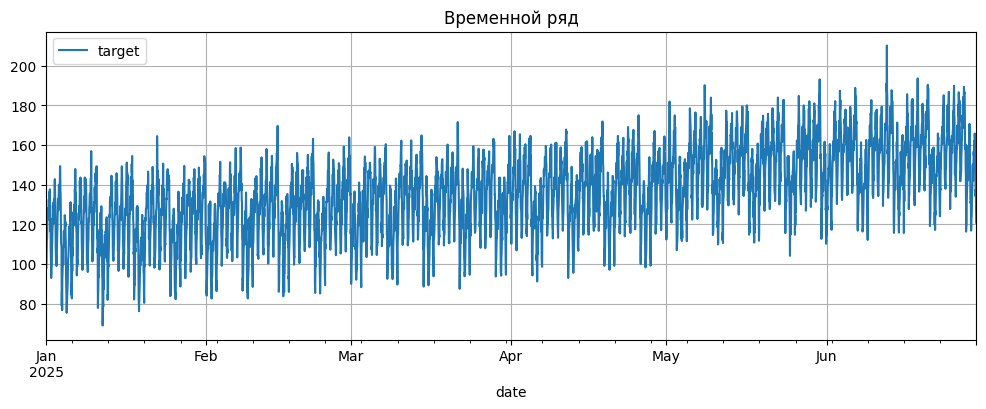

In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f"Размер датасета: {df.shape}")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Пропуски:\n{df.isnull().sum()}")
df.plot(x='date', y='target', title='Временной ряд', figsize=(12, 4))
print(df['target'].describe())
print(df.info())
df

- Тренд: восходящий - значения постепенно растут.
- Сезонность:  дневная.
- Выбросы: есть аномальные пики в каждом из месяцев
- Нестационарность: Ряд нестационарный из-за:
    - Наличия тренда (среднее меняется со временем)
    - Возможной изменяющейся дисперсии (амплитуда колебаний немного растёт)

,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


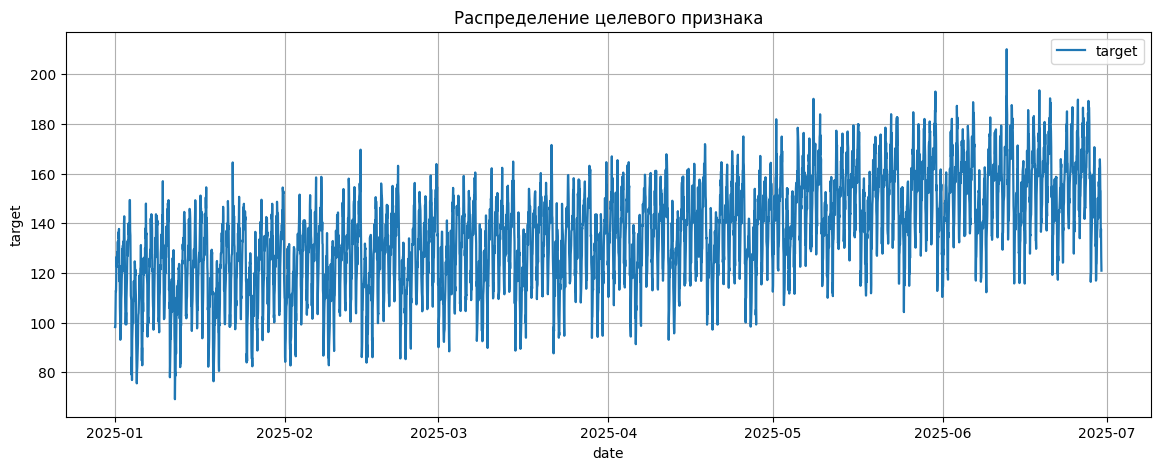

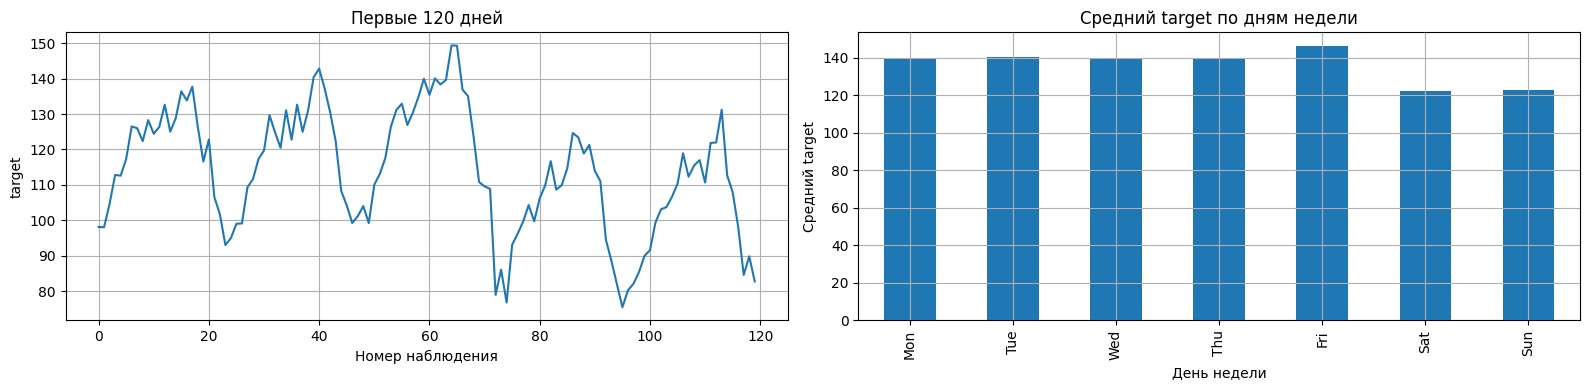

In [5]:
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Распределение целевого признака")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("target")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средний target по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний target")

plt.tight_layout()
plt.show()

In [6]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    for lag in [1, 7, 14, 28]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7
0,2025-01-02 04:00:00,111.64,3,1,0.433884,-0.900969,0.5,0.866025,109.33,106.54,128.87,98.14,100.545714,5.856307
1,2025-01-02 05:00:00,117.30,3,1,0.433884,-0.900969,0.5,0.866025,111.64,101.72,136.40,98.07,101.274286,6.942790
2,2025-01-02 06:00:00,119.72,3,1,0.433884,-0.900969,0.5,0.866025,117.30,93.04,133.85,104.70,103.500000,9.230043
3,2025-01-02 07:00:00,129.68,3,1,0.433884,-0.900969,0.5,0.866025,119.72,95.00,137.71,112.81,107.311429,9.688052
4,2025-01-02 08:00:00,124.85,3,1,0.433884,-0.900969,0.5,0.866025,129.68,99.05,126.32,112.62,112.265714,11.106433


train: 2025-01-02 → 2025-05-07 | 3004 строк
val:   2025-05-07 → 2025-06-03 | 644 строк
test:  2025-06-03 → 2025-06-29 | 644 строк


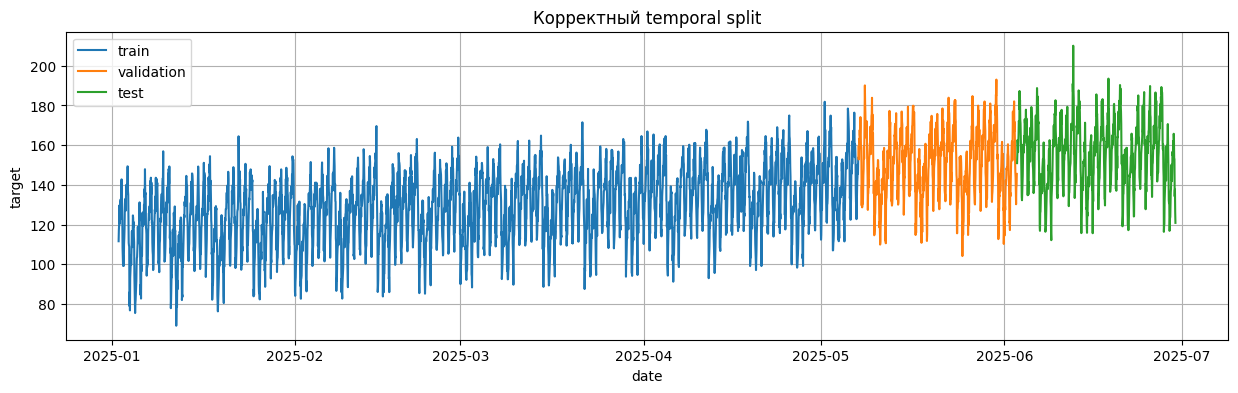

График сохранён: ./artifacts/figures/series_split.png


In [7]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(features_df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Корректный temporal split")
ax.set_xlabel("date")
ax.set_ylabel("target")
ax.legend()
plt.savefig(f"./artifacts/figures/series_split.png")
plt.show()

print(f"График сохранён: ./artifacts/figures/series_split.png")

Почему random split здесь некорректен - если мы перемешаем наблюдения случайно, модель будет учиться на поздних датах и тестироваться на ранних. Для прогноза это нереалистично.

In [8]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28 

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2976, 28, 1) y_train: (2976,)
X_val  : (616, 28, 1) y_val  : (616,)
X_test : (616, 28, 1) y_test : (616,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-0.9041106  -0.59782195 -0.46686465  0.0721167  -0.18925679]
Цель: -0.07778072


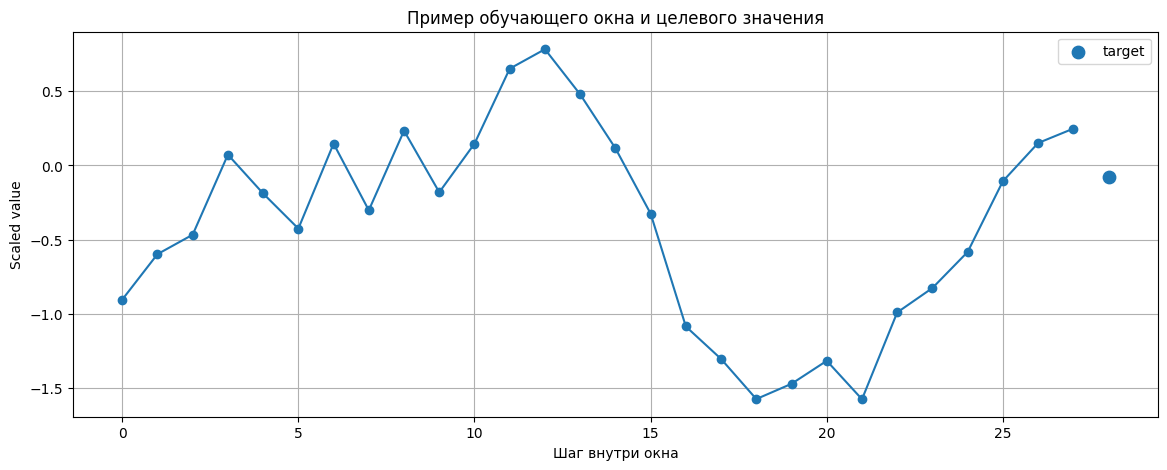

In [9]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [10]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32) 
        self.y = torch.tensor(y, dtype=torch.float32)  

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64 

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True) 
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)    
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  
print("Batch y:", yb.shape)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [11]:
feature_cols = [
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7",
]

target_col = "target"

train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3004, 12) | y_train: (3004,)
X_val:   (644, 12) | y_val:   (644,)
X_test:  (644, 12) | y_test:  (644,)


In [12]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

baseline_results_test = pd.concat([
    evaluate_regression(y_test, test_pred_naive, "Naive (lag_1)"),
    evaluate_regression(y_test, test_pred_ma7, "MovingAverage(7)"),
], ignore_index=True)

In [13]:
scaler_features = StandardScaler()
X_train_scaled = scaler_features.fit_transform(X_train)
X_val_scaled = scaler_features.transform(X_val)
X_test_scaled = scaler_features.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)

val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

test_results = pd.concat([
    baseline_results_test,
    evaluate_regression(y_test, test_pred_ridge, "Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,Naive (lag_1),6.441118,8.207078,4.393620
1,Ridge,6.582680,8.094044,4.386879
2,MovingAverage(7),12.697560,15.226533,8.812577


In [14]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))

def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [16]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7115 | val_loss=0.5390
Epoch 02 | train_loss=0.2906 | val_loss=0.3544
Epoch 03 | train_loss=0.1655 | val_loss=0.2061
Epoch 04 | train_loss=0.1563 | val_loss=0.2363
Epoch 05 | train_loss=0.1522 | val_loss=0.2249
Epoch 06 | train_loss=0.1485 | val_loss=0.2181
Epoch 07 | train_loss=0.1486 | val_loss=0.1814
Epoch 08 | train_loss=0.1459 | val_loss=0.1941
Epoch 09 | train_loss=0.1453 | val_loss=0.2060
Epoch 10 | train_loss=0.1457 | val_loss=0.2049
Epoch 11 | train_loss=0.1420 | val_loss=0.1939
Epoch 12 | train_loss=0.1408 | val_loss=0.1892
Epoch 13 | train_loss=0.1424 | val_loss=0.1769
Epoch 14 | train_loss=0.1384 | val_loss=0.2063
Epoch 15 | train_loss=0.1327 | val_loss=0.1822
Epoch 16 | train_loss=0.1276 | val_loss=0.1774
Epoch 17 | train_loss=0.1199 | val_loss=0.2119
Epoch 18 | train_loss=0.1128 | val_loss=0.2013
Epoch 19 | train_loss=0.1086 | val_loss=0.2763
Epoch 20 | train_loss=0.1075 | val_loss=0.2055
Epoch 21 | train_loss=0.1048 | val_loss=0

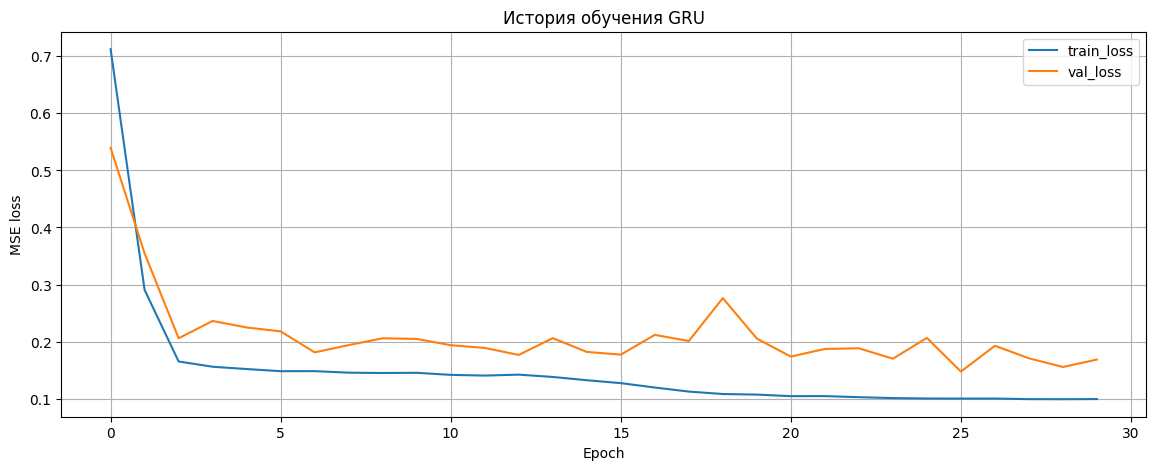

График сохранён: ./artifacts/figures/gru_learning_curves.png


In [17]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig(f"./artifacts/figures/gru_learning_curves.png")
plt.show()

print(f"График сохранён: ./artifacts/figures/gru_learning_curves.png")

In [18]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

def naive_baseline_from_windows(X: np.ndarray) -> np.ndarray:
    """
    Простой baseline: для каждого окна предсказываем последнее значение.
    Часто это хороший опорный результат для временных рядов.
    """
    return X[:, -1, 0]

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)

gru_val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

val_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(gru_val_true, gru_val_pred)},
    ]
).sort_values("RMSE")

val_metrics


,model,MAE,RMSE,MAPE
0,GRU,5.922701,7.601268,3.975537


In [19]:
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

test_true = inverse_scale(gru_test_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)

test_metrics = pd.DataFrame(
    [
        {"model": "GRU", **regression_metrics(test_true, gru_test_pred)},
    ]
).sort_values("RMSE")

test_metrics

,model,MAE,RMSE,MAPE
0,GRU,7.372356,9.331273,4.703383


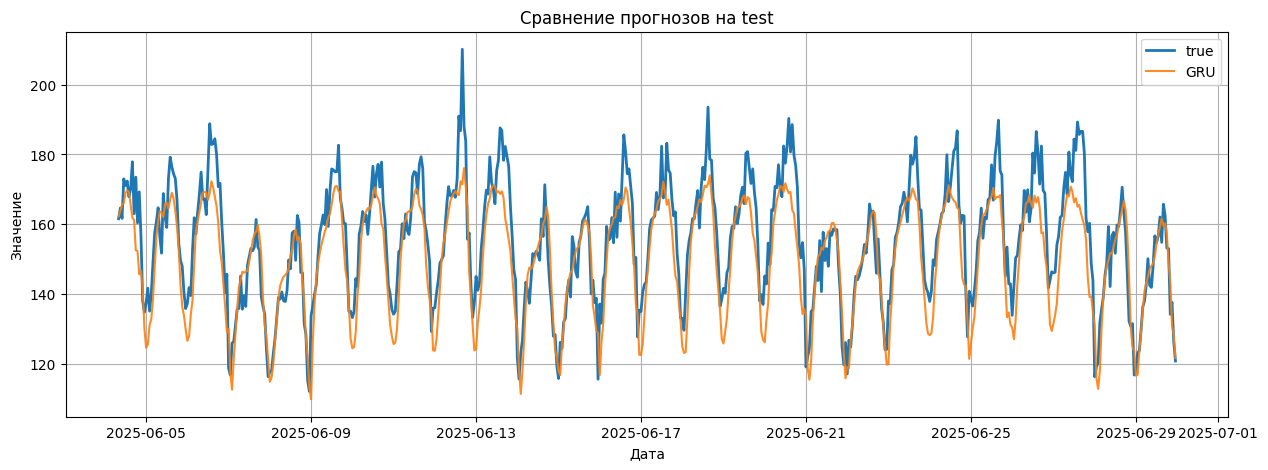

График сохранён: ./artifacts/figures/best_forecast_test.png


In [20]:
plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": test_true,
        "gru": gru_test_pred,
    }
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig(f"./artifacts/figures/best_forecast_test.png")
plt.show()

print(f"График сохранён: ./artifacts/figures/best_forecast_test.png")

In [21]:
results = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': 42,
        'split_summary': 'train 70% / val 15% / test 15%',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last',
        'features_summary': 'None',
        'scaler': None,
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': 6.441118,
        'best_val_rmse': 8.207078,
        'best_val_mape': 4.393620,
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'Baseline, прогноз последнее известное значение'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': 42,
        'split_summary': 'train 70% / val 15% / test 15%',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'moving-average',
        'features_summary': 'rolling_mean_7',
        'scaler': None,
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': 12.697560,
        'best_val_rmse': 15.226533,
        'best_val_mape': 8.812577,
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'Baseline, прогноз скользящее среднее'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': 42,
        'split_summary': 'train 70% / val 15% / test 15%',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'ridge-last-features',
        'features_summary': 'lag_1, 7, 14, 28; rolling_mean_7',
        'scaler': 'StandartScaler (features)',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': 6.582680,
        'best_val_rmse': 8.094044,
        'best_val_mape': 4.386879,
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'Линейная модель с lag, rolling'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': 42,
        'split_summary': 'train 70% / val 15% / test 15%',
        'window_size': 28,
        'horizon': 1,
        'model_summary': 'GRU',
        'features_summary': 'window_size=28',
        'scaler': 'StandartScaler (target)',
        'optimizer': 'Adam',
        'lr': 0.0005,
        'epochs_trained': 30,
        'best_val_mae': 5.720355,
        'best_val_rmse': 7.37221,
        'best_val_mape': 3.862717,
        'test_mae': 6.944059,
        'test_rmse': 8.805502,
        'test_mape': 4.462556,
        'notes': 'GRU-forecast. Лучшая модель по validation. Выбрана для test'
    },
]

df_runs = pd.DataFrame(results)

output_path = './artifacts/runs.csv'

df_runs.to_csv(output_path, index=False, encoding='utf-8')

In [22]:
tmp_path = './artifacts/best_gru.pt'
torch.save(gru_model.state_dict(), tmp_path)

In [23]:
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


ARTIFACTS_DIR = Path("artifacts")

best_config = {
    "experiment_id": "R1",
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "model_type": "GRUForecaster",
    "num_layers": 2,
    "window_size": 28,
    "horizon": 1,
    "split_summary": "70/15/15",
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "batch_size": 64,
    "epochs": 30,
    "scaler": "StandardScaler (target)",
    "best_val_mae": 5.720355,
    "best_val_rmse": 7.37221,
    "best_val_mape": 3.862717,
    "test_mae": 6.944059,
    "test_rmse": 8.805502,
    "test_mape": 4.462556,
}

save_json(best_config, ARTIFACTS_DIR / "best_gru_config.json")

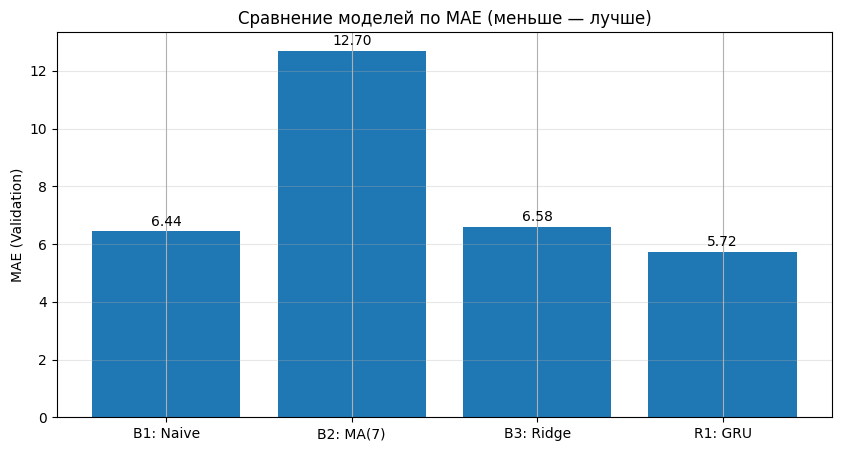

График сохранён: ./artifacts/figures/baselines_compare.png


In [24]:
models = ['B1: Naive', 'B2: MA(7)', 'B3: Ridge', 'R1: GRU']
mae = [6.441118, 12.697560, 6.582680, 5.720355]

# График
plt.figure(figsize=(10, 5))
plt.bar(models, mae)

# Значения на столбцах
for i, v in enumerate(mae):
    plt.text(i, v + 0.2, f'{v:.2f}', ha='center')

plt.ylabel('MAE (Validation)')
plt.title('Сравнение моделей по MAE (меньше — лучше)')
plt.grid(axis='y', alpha=0.3)
plt.savefig(f"./artifacts/figures/baselines_compare.png")
plt.show()

print(f"График сохранён: ./artifacts/figures/baselines_compare.png")